# net_fish_sonar_improved

Improved version of the `net_fish_sonar` dataset.

**Changes from `net_fish_sonar`:**
- The old `bag10` (200 manually-selected images from sequence `2024-08-20_17-14-36`) is **removed**.
- A new `bag10` is built from the same sequence using the ground-truth MOT annotations:
  every other frame that contains at least one fish instance is selected.
- All other bags (bag1–bag9) are copied unchanged from the original dataset.
- The bag-disjoint train/val/test split is re-optimised over all 10 bags.
- Annotations are exported in both YOLO and COCO JSON format.

**MOT → YOLO class mapping**

| MOT `class_id` | YOLO `class_id` | Name |
|:--------------:|:---------------:|:----:|
| 1 | 0 | fish |
| 2 | 1 | net  |

**gt.txt column order:** `timestamp, track_id, x_left, y_top, width, height, conf, class_id, vis`

In [1]:
from pathlib import Path
import shutil
import itertools
import json
import re
from collections import defaultdict, Counter

import pandas as pd

# =========================================================
# PATHS
# =========================================================
NOTEBOOK_DIR = Path.cwd()
SONAR_DIR    = NOTEBOOK_DIR.parent          # data-processing/sonar/

NET_FISH_SONAR_SPLIT = (
    SONAR_DIR / "net_fish_sonar" / "processed" / "split_yolo_fish_net"
)

MOT_SEQ_DIR = SONAR_DIR / "MOT" / "2024-08-20_17-14-36"
MOT_GT_PATH = MOT_SEQ_DIR / "gt" / "gt.txt"
MOT_FRAMES  = MOT_SEQ_DIR / "frames"

STAGING_IMAGES = NOTEBOOK_DIR / "processed" / "images"
STAGING_LABELS = NOTEBOOK_DIR / "processed" / "labels"
OUT_DIR        = NOTEBOOK_DIR / "processed"

# =========================================================
# CONSTANTS
# =========================================================
IMG_W, IMG_H = 1200, 700
IMAGE_EXTS   = {".jpg", ".jpeg", ".png", ".bmp"}

CLASS_ID_TO_NAME = {0: "fish", 1: "net"}
MOT_TO_YOLO      = {1: 0, 2: 1}   # fish: 1->0, net: 2->1

EXCLUDED_BAG = "bag10"   # replaced by the MOT-derived version

CLEAR_STAGING = True     # wipe staging area before re-running

# =========================================================
# SPLIT CONFIG (same as net_fish_sonar)
# =========================================================
TARGET_RATIOS = {"train": 0.60, "val": 0.20, "test": 0.20}
MIN_BAGS      = {"train": 4, "val": 2, "test": 2}
METRIC_WEIGHTS = {
    "images":            1.0,
    "background_images": 1.0,
    "fish_images":       1.2,
    "net_images":        1.2,
    "fish_instances":    1.5,
    "net_instances":     1.5,
}

print("Config OK")
print(f"  Source split : {NET_FISH_SONAR_SPLIT}")
print(f"  MOT sequence : {MOT_SEQ_DIR}")
print(f"  Staging      : {STAGING_IMAGES.parent}")
print(f"  Output       : {OUT_DIR}")

Config OK
  Source split : /workspace/aquaculture-perception/data-processing/sonar/net_fish_sonar/processed/split_yolo_fish_net
  MOT sequence : /workspace/aquaculture-perception/data-processing/sonar/MOT/2024-08-20_17-14-36
  Staging      : /workspace/aquaculture-perception/data-processing/sonar/net_fish_sonar_improved/processed
  Output       : /workspace/aquaculture-perception/data-processing/sonar/net_fish_sonar_improved/processed


## Step 1 — Select frames from the MOT sequence

Parse `gt.txt` for `2024-08-20_17-14-36` and select every frame that contains at least one
fish annotation (`class_id == 1`). All such frames are used since consecutive frames are
sufficiently dissimilar in this sonar recording.

In [2]:
# gt.txt has no header; columns in order:
#   timestamp, track_id, x_left, y_top, width, height, conf, class_id, vis
df_mot = pd.read_csv(
    MOT_GT_PATH,
    header=None,
    names=["timestamp", "track_id", "x_left", "y_top",
           "width", "height", "conf", "class_id", "vis"],
)

print(f"Annotation rows : {len(df_mot)}")
print(f"Unique frames   : {df_mot['timestamp'].nunique()}")
print("Class distribution:")
name_map = {1: "fish", 2: "net"}
for cid, cnt in df_mot["class_id"].value_counts().sort_index().items():
    print(f"  class {cid} ({name_map.get(int(cid), '?')}): {cnt}")

# Timestamps (frame IDs) that contain at least one fish annotation
fish_frame_set = set(df_mot.loc[df_mot["class_id"] == 1, "timestamp"])

# All frame timestamps in chronological order, filtered to fish frames
all_ts_sorted  = sorted(df_mot["timestamp"].unique())
selected_ts    = [ts for ts in all_ts_sorted if ts in fish_frame_set]

print(f"\nFish frames selected: {len(selected_ts)}")
print(f"  First timestamp   : {selected_ts[0]}")
print(f"  Last timestamp    : {selected_ts[-1]}")

Annotation rows : 1130
Unique frames   : 673
Class distribution:
  class 1 (fish): 457
  class 2 (net): 673

Fish frames selected: 336
  First timestamp   : 1724166880871875300
  Last timestamp    : 1724166922538784200


## Step 2 — Stage existing bags (bag1–bag9)

Copy all images and YOLO labels from the existing `net_fish_sonar` split,
skipping the old `bag10` entirely.

In [3]:
if CLEAR_STAGING and STAGING_IMAGES.parent.exists():
    shutil.rmtree(STAGING_IMAGES.parent)
    print("Cleared previous staging area")

STAGING_IMAGES.mkdir(parents=True, exist_ok=True)
STAGING_LABELS.mkdir(parents=True, exist_ok=True)

copied  = 0
skipped = 0

for split in ("train", "val", "test"):
    img_dir = NET_FISH_SONAR_SPLIT / "images" / split
    lbl_dir = NET_FISH_SONAR_SPLIT / "labels" / split

    for img_path in sorted(img_dir.iterdir()):
        if img_path.suffix.lower() not in IMAGE_EXTS:
            continue
        if img_path.stem.startswith(f"{EXCLUDED_BAG}_"):
            skipped += 1
            continue

        shutil.copy2(img_path, STAGING_IMAGES / img_path.name)

        lbl_src = lbl_dir / f"{img_path.stem}.txt"
        lbl_dst = STAGING_LABELS / f"{img_path.stem}.txt"
        if lbl_src.exists():
            shutil.copy2(lbl_src, lbl_dst)
        else:
            lbl_dst.write_text("", encoding="utf-8")

        copied += 1

print(f"Staged : {copied} images from bag1–bag9")
print(f"Skipped: {skipped} old {EXCLUDED_BAG} images")

Staged : 1800 images from bag1–bag9
Skipped: 200 old bag10 images


## Step 3 — Convert new bag10 (MOT → YOLO) and stage

For each selected frame:
1. Copy the raw image from `MOT/.../frames/<timestamp>.jpg` → `bag10_<timestamp>.jpg`.
2. Read **all** MOT annotations for that frame (both fish and net).
3. Convert from absolute pixel bboxes to YOLO normalised format and write the `.txt` label.

Conversion formulas (image size 1200 × 700):
```
x_center = (x_left + width  / 2) / IMG_W
y_center = (y_top  + height / 2) / IMG_H
w_norm   = width  / IMG_W
h_norm   = height / IMG_H
```

In [4]:
def mot_to_yolo(x_left, y_top, width, height, class_id_mot):
    """Convert a MOT bbox to YOLO normalised format."""
    x_c = (x_left + width  / 2) / IMG_W
    y_c = (y_top  + height / 2) / IMG_H
    w_n = width  / IMG_W
    h_n = height / IMG_H
    yolo_cls = MOT_TO_YOLO[int(class_id_mot)]
    return yolo_cls, x_c, y_c, w_n, h_n


staged_new    = 0
missing_frames = []

for ts in selected_ts:
    src_img = MOT_FRAMES / f"{ts}.jpg"
    dst_img = STAGING_IMAGES / f"bag10_{ts}.jpg"
    dst_lbl = STAGING_LABELS / f"bag10_{ts}.txt"

    if not src_img.exists():
        missing_frames.append(ts)
        continue

    shutil.copy2(src_img, dst_img)

    frame_anns = df_mot[df_mot["timestamp"] == ts]
    lines = []
    for _, row in frame_anns.iterrows():
        cls, xc, yc, wn, hn = mot_to_yolo(
            row["x_left"], row["y_top"], row["width"], row["height"], row["class_id"]
        )
        lines.append(f"{cls} {xc:.10f} {yc:.10f} {wn:.10f} {hn:.10f}")

    dst_lbl.write_text("\n".join(lines), encoding="utf-8")
    staged_new += 1

if missing_frames:
    print(f"WARNING: {len(missing_frames)} frame(s) not found on disk — skipped")

print(f"Staged new bag10: {staged_new} images with MOT-derived YOLO labels")
print(f"Total staging   : {sum(1 for p in STAGING_IMAGES.iterdir() if p.suffix.lower() in IMAGE_EXTS)} images")

Staged new bag10: 336 images with MOT-derived YOLO labels
Total staging   : 2136 images


## Step 4 — Staging area overview

In [5]:
def read_yolo_counts(lbl_path):
    """Return Counter({yolo_class_id: count}) for a YOLO label file."""
    counts = Counter()
    if lbl_path.exists():
        for line in lbl_path.read_text(encoding="utf-8").splitlines():
            parts = line.strip().split()
            if parts:
                counts[int(parts[0])] += 1
    return counts


records = []
for img_path in sorted(STAGING_IMAGES.iterdir()):
    if img_path.suffix.lower() not in IMAGE_EXTS:
        continue
    m = re.match(r"^(bag\d+)_", img_path.stem)
    if not m:
        continue
    bag_id   = m.group(1)
    lbl_path = STAGING_LABELS / f"{img_path.stem}.txt"
    counts   = read_yolo_counts(lbl_path)
    records.append({
        "image_name":     img_path.name,
        "bag_id":         bag_id,
        "fish_instances": counts.get(0, 0),
        "net_instances":  counts.get(1, 0),
    })

df_staging = pd.DataFrame(records)

bag_overview = (
    df_staging.groupby("bag_id")
    .agg(
        images        =("image_name",      "count"),
        fish_images   =("fish_instances",  lambda x: (x > 0).sum()),
        fish_instances=("fish_instances",  "sum"),
        net_images    =("net_instances",   lambda x: (x > 0).sum()),
        net_instances =("net_instances",   "sum"),
    )
    .reset_index()
    .sort_values("bag_id")
    .reset_index(drop=True)
)

bag_overview["fish_image_rate"] = bag_overview["fish_images"] / bag_overview["images"]

print("Staging area — per-bag summary:")
display(bag_overview)
print(f"\nTotal images    : {len(df_staging)}")
print(f"Total fish inst.: {df_staging['fish_instances'].sum()}")
print(f"Total net inst. : {df_staging['net_instances'].sum()}")

Staging area — per-bag summary:


,bag_id,images,fish_images,fish_instances,net_images,net_instances,fish_image_rate
0,bag1,200,37,69,200,200,0.185
1,bag10,336,336,457,336,336,1.000
2,bag2,200,58,141,200,200,0.290
3,bag3,200,25,31,200,200,0.125
4,bag4,200,41,127,200,200,0.205
5,bag5,200,0,0,200,200,0.000
6,bag6,200,0,0,200,200,0.000
7,bag7,200,16,22,200,200,0.080
8,bag8,200,0,0,200,200,0.000
9,bag9,200,33,75,200,200,0.165



Total images    : 2136
Total fish inst.: 922
Total net inst. : 2136


## Step 5 — Bag-level train/val/test split

The same bag assignment as the original `net_fish_sonar` dataset is used so results are
directly comparable. All images from one bag stay in a single split (no cross-bag leakage).

In [6]:
# Same bag assignment as net_fish_sonar (determined by exhaustive search in that notebook)
BAG_TO_SPLIT = {
    "bag1":  "test",
    "bag2":  "val",
    "bag3":  "train",
    "bag4":  "train",
    "bag5":  "val",
    "bag6":  "train",
    "bag7":  "train",
    "bag8":  "train",
    "bag9":  "test",
    "bag10": "train",
}

# Bag-level statistics for the summary display
bag_summary = (
    df_staging.assign(
        background  =(df_staging["fish_instances"] + df_staging["net_instances"]) == 0,
        fish_present= df_staging["fish_instances"] > 0,
        net_present = df_staging["net_instances"]  > 0,
    )
    .groupby("bag_id")
    .agg(
        images           =("image_name",    "count"),
        background_images=("background",    "sum"),
        fish_images      =("fish_present",  "sum"),
        net_images       =("net_present",   "sum"),
        fish_instances   =("fish_instances","sum"),
        net_instances    =("net_instances", "sum"),
    )
    .reset_index()
    .sort_values("bag_id")
    .reset_index(drop=True)
)
bag_summary["fish_image_rate"] = bag_summary["fish_images"] / bag_summary["images"]
bag_summary["net_image_rate"]  = bag_summary["net_images"]  / bag_summary["images"]

print("Bag summary:")
display(bag_summary)

print("\nBag assignment:")
for split in ("train", "val", "test"):
    bags = sorted(b for b, s in BAG_TO_SPLIT.items() if s == split)
    print(f"  {split}: {bags}")

Bag summary:


,bag_id,images,background_images,fish_images,net_images,fish_instances,net_instances,fish_image_rate,net_image_rate
0,bag1,200,0,37,200,69,200,0.185,1.0
1,bag10,336,0,336,336,457,336,1.000,1.0
2,bag2,200,0,58,200,141,200,0.290,1.0
3,bag3,200,0,25,200,31,200,0.125,1.0
4,bag4,200,0,41,200,127,200,0.205,1.0
5,bag5,200,0,0,200,0,200,0.000,1.0
6,bag6,200,0,0,200,0,200,0.000,1.0
7,bag7,200,0,16,200,22,200,0.080,1.0
8,bag8,200,0,0,200,0,200,0.000,1.0
9,bag9,200,0,33,200,75,200,0.165,1.0



Bag assignment:
  train: ['bag10', 'bag3', 'bag4', 'bag6', 'bag7', 'bag8']
  val: ['bag2', 'bag5']
  test: ['bag1', 'bag9']


In [7]:
df_staging["split"] = df_staging["bag_id"].map(BAG_TO_SPLIT)

split_summary = (
    df_staging.assign(
        background  =(df_staging["fish_instances"] + df_staging["net_instances"]) == 0,
        fish_present= df_staging["fish_instances"] > 0,
        net_present = df_staging["net_instances"]  > 0,
    )
    .groupby("split")
    .agg(
        bags            =("bag_id",         "nunique"),
        images          =("image_name",     "count"),
        background_images=("background",    "sum"),
        fish_images     =("fish_present",   "sum"),
        net_images      =("net_present",    "sum"),
        fish_instances  =("fish_instances", "sum"),
        net_instances   =("net_instances",  "sum"),
    )
    .reindex(["train", "val", "test"])
    .reset_index()
)
split_summary["image_ratio"]    = split_summary["images"] / len(df_staging)
split_summary["fish_image_rate"]= split_summary["fish_images"] / split_summary["images"]
split_summary["net_image_rate"] = split_summary["net_images"]  / split_summary["images"]

print("Split summary:")
display(split_summary)

Split summary:


,split,bags,images,background_images,fish_images,net_images,fish_instances,net_instances,image_ratio,fish_image_rate,net_image_rate
0,train,6,1336,0,418,1336,637,1336,0.625468,0.312874,1.0
1,val,2,400,0,58,400,141,400,0.187266,0.145000,1.0
2,test,2,400,0,70,400,144,400,0.187266,0.175000,1.0


## Step 6 — Write YOLO split to disk

In [8]:
# Clear only the split output subdirs — NOT the whole processed/ dir (staging lives there)
for subdir in ("images", "labels"):
    for split in ("train", "val", "test"):
        p = OUT_DIR / subdir / split
        if p.exists():
            shutil.rmtree(p)
ann_dir = OUT_DIR / "annotations"
if ann_dir.exists():
    shutil.rmtree(ann_dir)

for split in ("train", "val", "test"):
    (OUT_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (OUT_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

for row in df_staging.itertuples(index=False):
    split   = row.split
    src_img = STAGING_IMAGES / row.image_name
    src_lbl = STAGING_LABELS / f"{Path(row.image_name).stem}.txt"

    shutil.copy2(src_img, OUT_DIR / "images" / split / row.image_name)

    dst_lbl = OUT_DIR / "labels" / split / f"{Path(row.image_name).stem}.txt"
    if src_lbl.exists():
        shutil.copy2(src_lbl, dst_lbl)
    else:
        dst_lbl.write_text("", encoding="utf-8")

# CSV summaries
bag_assignment_df = bag_summary.copy()
bag_assignment_df["split"] = bag_assignment_df["bag_id"].map(BAG_TO_SPLIT)
bag_assignment_df = (
    bag_assignment_df.sort_values(["split", "bag_id"]).reset_index(drop=True)
)

df_staging.to_csv(OUT_DIR / "split_manifest.csv",      index=False)
bag_assignment_df.to_csv(OUT_DIR / "bag_assignment_summary.csv", index=False)
split_summary.to_csv(OUT_DIR / "split_summary.csv",    index=False)

# dataset.yaml (relative paths, for portability)
yaml_lines = [
    f"path: {OUT_DIR.as_posix()}",
    "train: images/train",
    "val:   images/val",
    "test:  images/test",
    "",
    "names:",
]
for cid, name in CLASS_ID_TO_NAME.items():
    yaml_lines.append(f"  {cid}: {name}")
(OUT_DIR / "dataset.yaml").write_text("\n".join(yaml_lines), encoding="utf-8")

# top-level yaml (absolute paths, convenient for training scripts)
top_yaml = "\n".join([
    f"train: {(OUT_DIR / 'images' / 'train').as_posix()}",
    f"val:   {(OUT_DIR / 'images' / 'val').as_posix()}",
    f"test:  {(OUT_DIR / 'images' / 'test').as_posix()}",
    "",
    "names:",
    "  - fish",
    "  - net",
])
(NOTEBOOK_DIR / "net_fish_sonar_improved.yaml").write_text(top_yaml, encoding="utf-8")

print(f"Wrote split to  : {OUT_DIR}")
print(f"dataset.yaml    : {OUT_DIR / 'dataset.yaml'}")
print(f"Top-level yaml  : {NOTEBOOK_DIR / 'net_fish_sonar_improved.yaml'}")
print(f"Manifest CSV    : {OUT_DIR / 'split_manifest.csv'}")

print("\nBag assignment table:")
display(bag_assignment_df)

Wrote split to  : /cluster/home/henrban/aquaculture-perception/data-processing/sonar/net_fish_sonar_improved/processed
dataset.yaml    : /cluster/home/henrban/aquaculture-perception/data-processing/sonar/net_fish_sonar_improved/processed/dataset.yaml
Top-level yaml  : /cluster/home/henrban/aquaculture-perception/data-processing/sonar/net_fish_sonar_improved/net_fish_sonar_improved.yaml
Manifest CSV    : /cluster/home/henrban/aquaculture-perception/data-processing/sonar/net_fish_sonar_improved/processed/split_manifest.csv

Bag assignment table:


,bag_id,images,background_images,fish_images,net_images,fish_instances,net_instances,fish_image_rate,net_image_rate,split
0,bag1,200,0,37,200,69,200,0.185,1.0,test
1,bag9,200,0,33,200,75,200,0.165,1.0,test
2,bag10,336,0,336,336,457,336,1.000,1.0,train
3,bag3,200,0,25,200,31,200,0.125,1.0,train
4,bag4,200,0,41,200,127,200,0.205,1.0,train
5,bag6,200,0,0,200,0,200,0.000,1.0,train
6,bag7,200,0,16,200,22,200,0.080,1.0,train
7,bag8,200,0,0,200,0,200,0.000,1.0,train
8,bag2,200,0,58,200,141,200,0.290,1.0,val
9,bag5,200,0,0,200,0,200,0.000,1.0,val


## Step 7 — COCO JSON annotations

Convert the YOLO labels to COCO JSON format for each split.
Bounding box format in COCO: `[x_min, y_min, width, height]` (absolute pixels).

In [2]:
from PIL import Image as PILImage


def yolo_line_to_coco_bbox(parts, img_w, img_h):
    cls_id = int(float(parts[0]))
    x_c = float(parts[1]) * img_w
    y_c = float(parts[2]) * img_h
    bw  = float(parts[3]) * img_w
    bh  = float(parts[4]) * img_h
    x_min = max(0.0, x_c - bw / 2)
    y_min = max(0.0, y_c - bh / 2)
    bw = min(bw, img_w - x_min)
    bh = min(bh, img_h - y_min)
    return cls_id, [x_min, y_min, bw, bh]


def build_coco(split):
    image_dir  = OUT_DIR / "images" / split
    label_dir  = OUT_DIR / "labels" / split
    categories = [{"id": i + 1, "name": n} for i, n in CLASS_ID_TO_NAME.items()]
    images, annotations = [], []
    ann_id = img_id = 1

    for img_path in sorted(
        p for p in image_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS
    ):
        with PILImage.open(img_path) as im:
            w, h = im.size
        images.append({"id": img_id, "file_name": img_path.name, "width": w, "height": h})

        lbl_path = label_dir / f"{img_path.stem}.txt"
        if lbl_path.exists():
            for line in lbl_path.read_text(encoding="utf-8").splitlines():
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cls_id, bbox = yolo_line_to_coco_bbox(parts, w, h)
                x, y, bw, bh = bbox
                if bw <= 0 or bh <= 0:
                    continue
                annotations.append({
                    "id":          ann_id,
                    "image_id":    img_id,
                    "category_id": cls_id + 1,
                    "bbox":        [x, y, bw, bh],
                    "area":        bw * bh,
                    "iscrowd":     0,
                    "segmentation": [],
                })
                ann_id += 1

        img_id += 1

    return {"images": images, "annotations": annotations, "categories": categories}


ann_dir = OUT_DIR / "annotations"
ann_dir.mkdir(exist_ok=True)

for split in ("train", "val", "test"):
    coco = build_coco(split)
    out_path = ann_dir / f"{split}.json"
    with open(out_path, "w") as f:
        json.dump(coco, f)
    print(f"[{split}]  {len(coco['images']):5d} images | {len(coco['annotations']):6d} annotations")

[train]   1336 images |   1973 annotations
[val]    400 images |    541 annotations
[test]    400 images |    565 annotations


## Summary

## Bounding box inspection

Shows every image in the chosen split that contains at least one fish annotation.
All bounding boxes are drawn: **fish** in red, **net** in cyan.

Split 'test': 70 images with fish


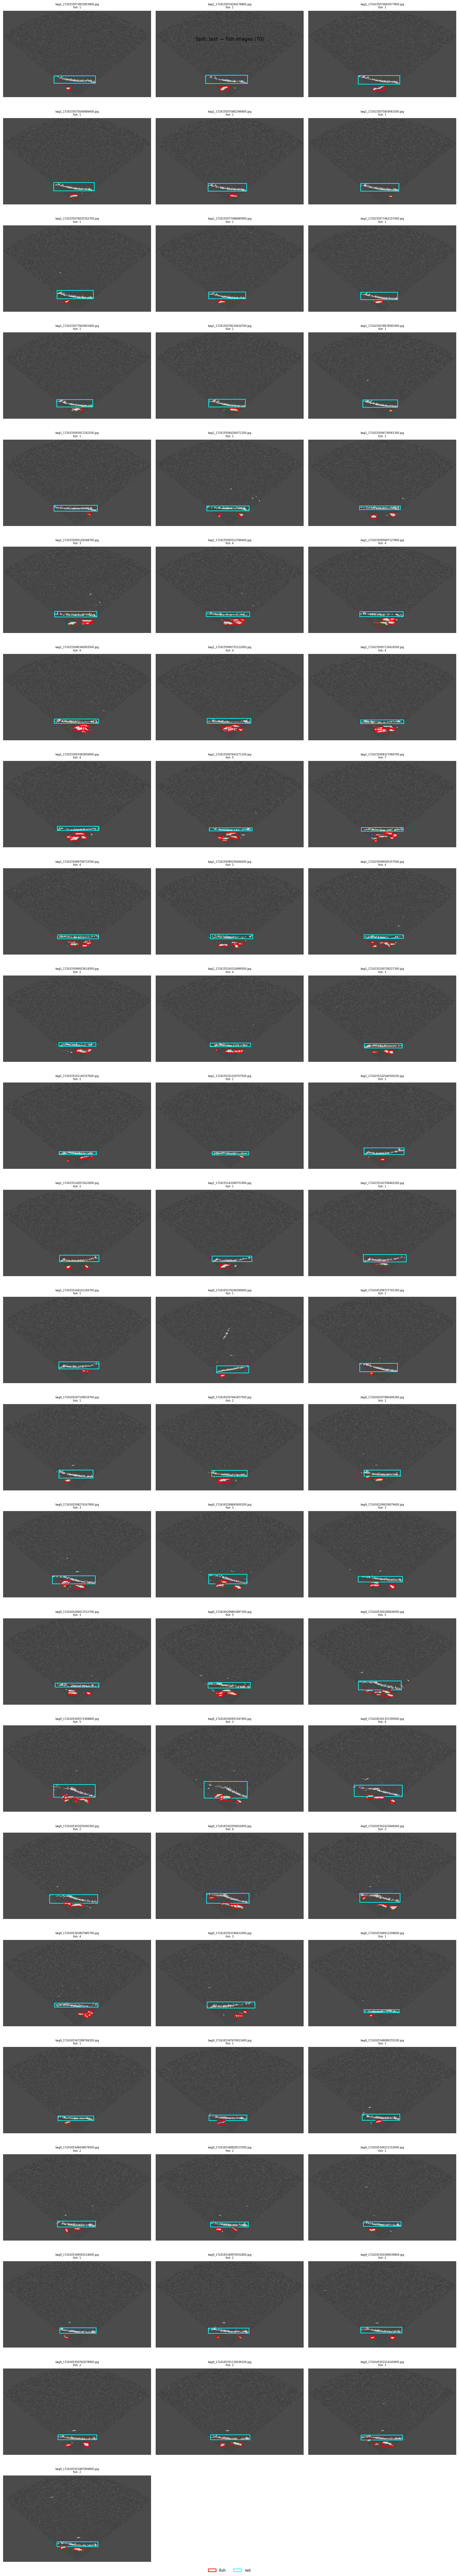

In [3]:
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image as PILImage

# ---- config ----
INSPECT_SPLIT = "test"   # "train" / "val" / "test"
COLS = 3                 # images per row

CLASS_COLORS = {0: "red", 1: "cyan"}   # fish=red, net=cyan
CLASS_NAMES  = {0: "fish", 1: "net"}

# ---- collect fish images ----
img_dir = OUT_DIR / "images" / INSPECT_SPLIT
lbl_dir = OUT_DIR / "labels" / INSPECT_SPLIT

fish_images = []
for img_path in sorted(p for p in img_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS):
    lbl_path = lbl_dir / f"{img_path.stem}.txt"
    if not lbl_path.exists():
        continue
    lines = [l.strip() for l in lbl_path.read_text(encoding="utf-8").splitlines() if l.strip()]
    n_fish = sum(1 for l in lines if int(l.split()[0]) == 0)
    if n_fish > 0:
        fish_images.append((img_path, lines, n_fish))

print(f"Split '{INSPECT_SPLIT}': {len(fish_images)} images with fish")

# ---- plot ----
n = len(fish_images)
rows = math.ceil(n / COLS)

fig, axes = plt.subplots(rows, COLS, figsize=(COLS * 5, rows * 3.5))
axes = axes.flatten() if n > 1 else [axes]

for ax, (img_path, lines, n_fish) in zip(axes, fish_images):
    img = PILImage.open(img_path)
    W, H = img.size
    ax.imshow(img, cmap="gray")
    ax.set_title(f"{img_path.name}\nfish: {n_fish}", fontsize=6)
    ax.axis("off")

    for line in lines:
        parts = line.split()
        cls = int(parts[0])
        xc, yc, wn, hn = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
        x0 = (xc - wn / 2) * W
        y0 = (yc - hn / 2) * H
        rect = mpatches.Rectangle(
            (x0, y0), wn * W, hn * H,
            linewidth=1.5, edgecolor=CLASS_COLORS.get(cls, "white"), facecolor="none",
        )
        ax.add_patch(rect)

for ax in axes[len(fish_images):]:
    ax.set_visible(False)

legend_patches = [
    mpatches.Patch(edgecolor=c, facecolor="none", label=CLASS_NAMES[k], linewidth=1.5)
    for k, c in CLASS_COLORS.items()
]
fig.legend(handles=legend_patches, loc="lower center", ncol=2, fontsize=9, frameon=False)
plt.suptitle(f"Split: {INSPECT_SPLIT} — fish images ({n})", fontsize=11)
plt.tight_layout()
plt.show()

In [2]:
def count_split(split):
    img_dir = OUT_DIR / "images" / split
    lbl_dir = OUT_DIR / "labels" / split
    n_images    = sum(1 for p in img_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS)
    n_instances = sum(
        sum(1 for ln in p.read_text(encoding="utf-8").splitlines() if ln.strip())
        for p in lbl_dir.iterdir() if p.suffix == ".txt"
    )
    return n_images, n_instances


total_images = total_instances = 0
for split in ("train", "val", "test"):
    n_img, n_inst = count_split(split)
    total_images     += n_img
    total_instances  += n_inst
    print(f"{split:5s}  images={n_img:5d}  instances={n_inst:6d}")
print(f"{'total':5s}  images={total_images:5d}  instances={total_instances:6d}")

train  images= 1336  instances=  1973
val    images=  400  instances=   541
test   images=  400  instances=   565
total  images= 2136  instances=  3079


In [2]:
# Bag → full sequence name mapping (from net_fish_sonar/net_fish_sonar.ipynb)
# net_fish_sonar_improved keeps the same 10 bags but replaces bag10 with
# MOT-derived annotations from the same sequence.
import pandas as pd

BAG_NAMES = {
    "bag1":  "2024-08-20_13-57-42",
    "bag2":  "2024-08-20_17-02-00",
    "bag3":  "2024-08-20_13-55-34",
    "bag4":  "2024-08-20_14-31-29",
    "bag5":  "2024-08-20_14-38-37",
    "bag6":  "2024-08-20_14-34-07",
    "bag7":  "2024-08-20_14-16-05",
    "bag8":  "2024-08-20_18-50-22",
    "bag9":  "2024-08-20_16-47-54",
    "bag10": "2024-08-20_17-14-36",   # MOT-derived in this dataset
}

SPLIT_BAGS = {
    "train": ["bag3", "bag4", "bag6", "bag7", "bag8", "bag10"],
    "val":   ["bag2", "bag5"],
    "test":  ["bag1", "bag9"],
}

rows = [
    {"split": split, "bag_id": bag_id, "sequence": BAG_NAMES[bag_id]}
    for split, bags in SPLIT_BAGS.items()
    for bag_id in bags
]

split_order = pd.CategoricalDtype(["train", "val", "test"], ordered=True)
split_table = (
    pd.DataFrame(rows)
    .assign(split=lambda d: d["split"].astype(split_order))
    .sort_values(["split", "bag_id"])
    .reset_index(drop=True)
)

display(split_table)


,split,bag_id,sequence
0,train,bag10,2024-08-20_17-14-36
1,train,bag3,2024-08-20_13-55-34
2,train,bag4,2024-08-20_14-31-29
3,train,bag6,2024-08-20_14-34-07
4,train,bag7,2024-08-20_14-16-05
5,train,bag8,2024-08-20_18-50-22
6,val,bag2,2024-08-20_17-02-00
7,val,bag5,2024-08-20_14-38-37
8,test,bag1,2024-08-20_13-57-42
9,test,bag9,2024-08-20_16-47-54
